# CS-GY 6513-C Big Data - Final Project

**Semester:** spring 2026  
**NetID:** wy889, shl8628  
**Name:** Wensheng(Wessel) Yu, Shifa Ladak

## Part 1: Setup & Data Loading

Load 2026 March first:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession

In [2]:
import numpy as np

In [3]:
# Display plots inside the notebook
%matplotlib inline

players_03 = pd.read_csv("202603/players.csv")
players_03.head()

,player_slot,obs_placed,sen_placed,creeps_stacked,camps_stacked,rune_pickups,firstblood_claimed,teamfight_participation,towers_killed,roshans_killed,...,benchmarks,purchase_tpscroll,match_id,leagueid,purchase_gem,additional_units,purchase_rapier,performance_others,computed_mmr,repicked
0,0,0.0,0.0,6.0,2.0,1.0,0.0,0.222222,0.0,0.0,...,"{'gold_per_min': {'raw': 509, 'pct': 0.2315020...",NaN,8710914747,18959,NaN,NaN,NaN,NaN,NaN,NaN
1,1,9.0,9.0,0.0,0.0,2.0,0.0,0.722222,0.0,0.0,...,"{'gold_per_min': {'raw': 351, 'pct': 0.2372764...",1.0,8710914747,18959,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0.0,0.0,0.0,0.0,3.0,0.0,0.611111,0.0,0.0,...,"{'gold_per_min': {'raw': 463, 'pct': 0.5146942...",1.0,8710914747,18959,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2.0,0.0,0.0,0.0,1.0,0.0,0.500000,2.0,0.0,...,"{'gold_per_min': {'raw': 495, 'pct': 0.4366647...",1.0,8710914747,18959,NaN,NaN,NaN,NaN,NaN,NaN
4,4,3.0,16.0,0.0,0.0,2.0,0.0,0.333333,0.0,0.0,...,"{'gold_per_min': {'raw': 281, 'pct': 0.1801863...",1.0,8710914747,18959,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Display columns
players_03.columns

Index(['player_slot', 'obs_placed', 'sen_placed', 'creeps_stacked',
       'camps_stacked', 'rune_pickups', 'firstblood_claimed',
       'teamfight_participation', 'towers_killed', 'roshans_killed',
       ...
       'benchmarks', 'purchase_tpscroll', 'match_id', 'leagueid',
       'purchase_gem', 'additional_units', 'purchase_rapier',
       'performance_others', 'computed_mmr', 'repicked'],
      dtype='str', length=152)

In [5]:
# See all columns
pd.set_option('display.max_columns', None)
players_03.head()

,player_slot,obs_placed,sen_placed,creeps_stacked,camps_stacked,rune_pickups,firstblood_claimed,teamfight_participation,towers_killed,roshans_killed,observers_placed,stuns,max_hero_hit,times,gold_t,lh_t,dn_t,xp_t,obs_log,sen_log,obs_left_log,sen_left_log,purchase_log,kills_log,buyback_log,runes_log,connection_log,lane_pos,obs,sen,actions,pings,purchase,gold_reasons,xp_reasons,killed,item_uses,ability_uses,ability_targets,damage_targets,hero_hits,damage,damage_taken,damage_inflictor,runes,killed_by,kill_streaks,multi_kills,life_state,healing,damage_inflictor_received,randomed,pred_vict,neutral_tokens_log,neutral_item_history,account_id,party_id,permanent_buffs,party_size,team_number,team_slot,hero_id,hero_variant,item_0,item_1,item_2,item_3,item_4,item_5,backpack_0,backpack_1,backpack_2,item_neutral,item_neutral2,kills,deaths,assists,leaver_status,last_hits,denies,gold_per_min,xp_per_min,level,net_worth,aghanims_scepter,aghanims_shard,moonshard,hero_damage,tower_damage,hero_healing,gold,gold_spent,ability_upgrades_arr,personaname,name,last_login,rank_tier,is_subscriber,radiant_win,start_time,duration,cluster,lobby_type,game_mode,is_contributor,patch,region,isRadiant,win,lose,total_gold,total_xp,kills_per_min,kda,abandons,neutral_kills,tower_kills,courier_kills,lane_kills,hero_kills,observer_kills,sentry_kills,roshan_kills,necronomicon_kills,ancient_kills,buyback_count,observer_uses,sentry_uses,lane_efficiency,lane_efficiency_pct,lane,lane_role,is_roaming,purchase_time,first_purchase_time,item_win,item_usage,purchase_ward_observer,purchase_ward_sentry,actions_per_min,life_state_dead,cosmetics,benchmarks,purchase_tpscroll,match_id,leagueid,purchase_gem,additional_units,purchase_rapier,performance_others,computed_mmr,repicked
0,0,0.0,0.0,6.0,2.0,1.0,0.0,0.222222,0.0,0.0,0.0,-2.965871,"{'time': 1526, 'type': 'max_hero_hit', 'unit':...","[0, 60, 120, 180, 240, 300, 360, 420, 480, 540...","[0, 258, 457, 759, 1176, 1548, 1943, 2447, 308...","[0, 2, 5, 9, 16, 21, 28, 38, 44, 50, 66, 66, 8...","[0, 0, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5, 5, 5, ...","[0, 90, 417, 640, 876, 1112, 1455, 1960, 2338,...",[],[],[],[],"[{'time': -89, 'key': 'branches'}, {'time': -8...","[{'time': 433, 'key': 'npc_dota_hero_dawnbreak...",[],"[{'time': 757, 'key': '5'}]",[],"{'74': {'78': 2}, '76': {'76': 7, '77': 1, '79...",{},{},"{'1': 3811, '2': 11, '4': 1344, '5': 17, '6': ...",7.0,"{'power_treads': 1, 'staff_of_wizardry': 1, 'b...","{'0': 600, '1': -1697, '6': 1992, '11': 270, '...","{'0': 41, '1': 1890, '2': 13562}","{'npc_dota_neutral_mud_golem': 6, 'npc_dota_ne...","{'power_treads': 147, 'tpscroll': 5, 'madstone...","{'plus_high_five': 1, 'nevermore_shadowraze2':...",{},{'nevermore_shadowraze2': {'npc_dota_hero_rubi...,"{'null': 22, 'nevermore_shadowraze2': 13, 'nev...","{'npc_dota_neutral_mud_golem': 4986, 'npc_dota...","{'npc_dota_neutral_mud_golem': 48, 'npc_dota_h...","{'null': 1661, 'nevermore_shadowraze2': 2685, ...",{'5': 1},"{'npc_dota_hero_storm_spirit': 3, 'npc_dota_he...",{},{},"{'0': 1463, '1': 12, '2': 290}",{'npc_dota_hero_nevermore': 1596},"{'null': 2636, 'dawnbreaker_converge': 416, 'o...",False,False,[],"[{'item_neutral': 'weighted_dice', 'time': 417...",3.972061e+08,0.0,[],10,0,0,11,1.0,16,63,152,277,16,1,0,0,0,1599,1576.0,3,7,1,0.0,266,7,509,526,16,11808,0.0,0.0,0.0,14536,877,0,598,15285,"[5059, 5063, 5059, 5063, 5059, 5064, 5059, 506...",Kintaro,NaN,2022-04-04T18:05:22.488Z,80.0,False,False,1772334788,1764,273,1,2,False,59,3.0,True,0.0,1.0,14964,15464.0,0.102041,0.50,0.0,122.0,0.0,0.0,143.0,3.0,0.0,0.0,0.0,0.0,11.0,0.0,0.0,0.0,0.804568,80.0,1.0,1.0,False,"{'branches': -178, 'magic_wand': -89, 'tango':...","{'branches': -89, 'magic_wand': -89, 'tango': ...","{'branches': 0, 'magic_wand': 0, 'tango': 0, '...","{'branches': 1, 'magic_wand': 1, 'tango': 1, '...",NaN,NaN,189.0,302.0,[],"{'gold_per_min': {'raw': 509, 'pct': 0.2315020...",NaN,8710914747,18959,NaN,NaN,NaN,NaN,NaN,NaN
1,1,9.0,9.0,0.0,0.0,2.0,0.0,0.722222,0.0,0.0,9.0,40.663810,"{'t

In [6]:
bp_03 = pd.read_csv("202603/picks_bans.csv")
bp_03.head()

,is_pick,hero_id,team,order,match_id,leagueid
0,False,92,1,0,8710914747,18959
1,False,40,1,1,8710914747,18959
2,False,102,0,2,8710914747,18959
3,False,120,0,3,8710914747,18959
4,False,16,1,4,8710914747,18959


# Part 2: Data Preparation

## 2.1 openDota hero mapping

Map hero names with their hero id. (data from opendota)

In [7]:
import requests

heroes = requests.get("https://api.opendota.com/api/heroes").json()
hero_df = pd.DataFrame(heroes)

hero_df[['id', 'localized_name']].head()

,id,localized_name
0,1,Anti-Mage
1,2,Axe
2,3,Bane
3,4,Bloodseeker
4,5,Crystal Maiden


In [8]:
players_03 = players_03.merge(
    hero_df[['id', 'localized_name']],
    left_on='hero_id',
    right_on='id',
    how='left'
)

In [9]:
players_03.head()

,player_slot,obs_placed,sen_placed,creeps_stacked,camps_stacked,rune_pickups,firstblood_claimed,teamfight_participation,towers_killed,roshans_killed,observers_placed,stuns,max_hero_hit,times,gold_t,lh_t,dn_t,xp_t,obs_log,sen_log,obs_left_log,sen_left_log,purchase_log,kills_log,buyback_log,runes_log,connection_log,lane_pos,obs,sen,actions,pings,purchase,gold_reasons,xp_reasons,killed,item_uses,ability_uses,ability_targets,damage_targets,hero_hits,damage,damage_taken,damage_inflictor,runes,killed_by,kill_streaks,multi_kills,life_state,healing,damage_inflictor_received,randomed,pred_vict,neutral_tokens_log,neutral_item_history,account_id,party_id,permanent_buffs,party_size,team_number,team_slot,hero_id,hero_variant,item_0,item_1,item_2,item_3,item_4,item_5,backpack_0,backpack_1,backpack_2,item_neutral,item_neutral2,kills,deaths,assists,leaver_status,last_hits,denies,gold_per_min,xp_per_min,level,net_worth,aghanims_scepter,aghanims_shard,moonshard,hero_damage,tower_damage,hero_healing,gold,gold_spent,ability_upgrades_arr,personaname,name,last_login,rank_tier,is_subscriber,radiant_win,start_time,duration,cluster,lobby_type,game_mode,is_contributor,patch,region,isRadiant,win,lose,total_gold,total_xp,kills_per_min,kda,abandons,neutral_kills,tower_kills,courier_kills,lane_kills,hero_kills,observer_kills,sentry_kills,roshan_kills,necronomicon_kills,ancient_kills,buyback_count,observer_uses,sentry_uses,lane_efficiency,lane_efficiency_pct,lane,lane_role,is_roaming,purchase_time,first_purchase_time,item_win,item_usage,purchase_ward_observer,purchase_ward_sentry,actions_per_min,life_state_dead,cosmetics,benchmarks,purchase_tpscroll,match_id,leagueid,purchase_gem,additional_units,purchase_rapier,performance_others,computed_mmr,repicked,id,localized_name
0,0,0.0,0.0,6.0,2.0,1.0,0.0,0.222222,0.0,0.0,0.0,-2.965871,"{'time': 1526, 'type': 'max_hero_hit', 'unit':...","[0, 60, 120, 180, 240, 300, 360, 420, 480, 540...","[0, 258, 457, 759, 1176, 1548, 1943, 2447, 308...","[0, 2, 5, 9, 16, 21, 28, 38, 44, 50, 66, 66, 8...","[0, 0, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5, 5, 5, ...","[0, 90, 417, 640, 876, 1112, 1455, 1960, 2338,...",[],[],[],[],"[{'time': -89, 'key': 'branches'}, {'time': -8...","[{'time': 433, 'key': 'npc_dota_hero_dawnbreak...",[],"[{'time': 757, 'key': '5'}]",[],"{'74': {'78': 2}, '76': {'76': 7, '77': 1, '79...",{},{},"{'1': 3811, '2': 11, '4': 1344, '5': 17, '6': ...",7.0,"{'power_treads': 1, 'staff_of_wizardry': 1, 'b...","{'0': 600, '1': -1697, '6': 1992, '11': 270, '...","{'0': 41, '1': 1890, '2': 13562}","{'npc_dota_neutral_mud_golem': 6, 'npc_dota_ne...","{'power_treads': 147, 'tpscroll': 5, 'madstone...","{'plus_high_five': 1, 'nevermore_shadowraze2':...",{},{'nevermore_shadowraze2': {'npc_dota_hero_rubi...,"{'null': 22, 'nevermore_shadowraze2': 13, 'nev...","{'npc_dota_neutral_mud_golem': 4986, 'npc_dota...","{'npc_dota_neutral_mud_golem': 48, 'npc_dota_h...","{'null': 1661, 'nevermore_shadowraze2': 2685, ...",{'5': 1},"{'npc_dota_hero_storm_spirit': 3, 'npc_dota_he...",{},{},"{'0': 1463, '1': 12, '2': 290}",{'npc_dota_hero_nevermore': 1596},"{'null': 2636, 'dawnbreaker_converge': 416, 'o...",False,False,[],"[{'item_neutral': 'weighted_dice', 'time': 417...",3.972061e+08,0.0,[],10,0,0,11,1.0,16,63,152,277,16,1,0,0,0,1599,1576.0,3,7,1,0.0,266,7,509,526,16,11808,0.0,0.0,0.0,14536,877,0,598,15285,"[5059, 5063, 5059, 5063, 5059, 5064, 5059, 506...",Kintaro,NaN,2022-04-04T18:05:22.488Z,80.0,False,False,1772334788,1764,273,1,2,False,59,3.0,True,0.0,1.0,14964,15464.0,0.102041,0.50,0.0,122.0,0.0,0.0,143.0,3.0,0.0,0.0,0.0,0.0,11.0,0.0,0.0,0.0,0.804568,80.0,1.0,1.0,False,"{'branches': -178, 'magic_wand': -89, 'tango':...","{'branches': -89, 'magic_wand': -89, 'tango': ...","{'branches': 0, 'magic_wand': 0, 'tango': 0, '...","{'branches': 1, 'magic_wand': 1, 'tango': 1, '...",NaN,NaN,189.0,302.0,[],"{'gold_per_min': {'raw': 509, 'pct': 0.2315020...",NaN,8710914747,18959,NaN,NaN,NaN,NaN,NaN,NaN,11,Shadow Fiend
1,1,9.0,9.0,0.0,0.0,2.0,0.0,0

In [10]:
players_03.info()

<class 'pandas.DataFrame'>
RangeIndex: 24130 entries, 0 to 24129
Columns: 154 entries, player_slot to localized_name
dtypes: bool(7), float64(54), int64(39), str(54)
memory usage: 488.8 MB


##  2.2 Handle Purchase

Take a look into the column "purchase"

In [11]:
players_03['purchase']

0        {'power_treads': 1, 'staff_of_wizardry': 1, 'b...
1        {'ward_sentry': 10, 'recipe_arcane_boots': 1, ...
2        {'tpscroll': 1, 'gauntlets': 2, 'point_booster...
3        {'power_treads': 1, 'recipe_wraith_band': 2, '...
4        {'ward_sentry': 18, 'recipe_arcane_boots': 1, ...
                               ...                        
24125    {'power_treads': 1, 'armlet': 1, 'helm_of_iron...
24126    {'power_treads': 1, 'staff_of_wizardry': 2, 'b...
24127    {'ward_sentry': 14, 'arcane_boots': 1, 'recipe...
24128    {'ward_sentry': 9, 'recipe_arcane_boots': 1, '...
24129    {'power_treads': 1, 'void_stone': 1, 'pers': 1...
Name: purchase, Length: 24130, dtype: str

We can see that the structure of it is a list of {'item name': how many times the item was bought}

So we create a column 'purchase_dict' to clearly check what items a player had bought.

In [12]:
import ast
# Import Abstract Syntax Trees module to help evaluate strings

players_03['purchase_dict'] = players_03['purchase'].apply(
    lambda x: ast.literal_eval(x) if pd.notnull(x) else {}
)

/tmp/ipykernel_6246/351209331.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  players_03['purchase_dict'] = players_03['purchase'].apply(


# Part 3: First Simple Analysis: BKB vs. win rate

The relationship between whether a player bought a BKB (Item: Black King Bar) vs. their win rate

Each game includes two sides: Radiant vs. Dire

In this Data frame. If player_slot < 128 (from 0 to 4), then this player belongs to Radiant. Otherwise (player_slot is from 128 to 132), this player belongs to Dire.

## 3.1 Extract useful features

In [13]:
# Define win_rate according to player slots.
def is_win(row):
    if row['player_slot'] < 128:
        return row['radiant_win'] == True
    else:
        return row['radiant_win'] == False

# Apply the function to each row
players_03['win'] = players_03.apply(is_win, axis=1)

In [14]:
# Create a new column names has_bkb

players_03['has_bkb'] = players_03['purchase_dict'].apply(
    lambda x: 'black_king_bar' in x
)

/tmp/ipykernel_6246/978825370.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  players_03['has_bkb'] = players_03['purchase_dict'].apply(


In [15]:
players_03.groupby('has_bkb')['win'].mean()

has_bkb
False    0.485799
True     0.547265
Name: win, dtype: float64

## 3.2 Visualize

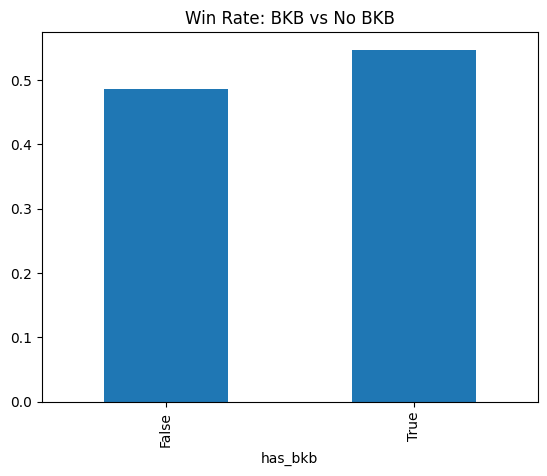

In [16]:
import matplotlib.pyplot as plt

players_03.groupby('has_bkb')['win'].mean().plot(kind='bar')
plt.title("Win Rate: BKB vs No BKB")
plt.show()

## Part 3.3: Extended Analysis: Impact of Gold Advantage

The initial result suggests that purchasing a Black King Bar (BKB) slightly improves win rate. However, this effect appears smaller than expected given the importance of BKB in professional gameplay.

One possible explanation is that the impact of BKB depends on the overall game context. In particular, when a team already has a significant economic advantage, the outcome of the game may be largely determined regardless of specific item choices.

To account for this, we introduce an additional dimension based on gold advantage:

- We define a "stomp" game as one where the winning team has a final gold advantage greater than 15,000.
- We then compare the win rate of players with and without BKB under two conditions:
  1. Non-stomp games (more balanced)
  2. Stomp games (one-sided)

This allows us to evaluate whether BKB is more impactful in competitive situations compared to already decided matches.

In [17]:
gold_adv_03 = pd.read_csv("202603/radiant_gold_adv.csv")

In [18]:
gold_adv_03.head()

,minute,gold,match_id,leagueid
0,1,0.0,8710914747,18959
1,2,-84.0,8710914747,18959
2,3,-304.0,8710914747,18959
3,4,-341.0,8710914747,18959
4,5,-205.0,8710914747,18959


This data frame shows gold advantage according to time, but we only need the final gold advantage.

In [19]:
# Get final gold advantage for each match
final_gold_adv_03 = (
    gold_adv_03
    .sort_values(['match_id', 'minute'])
    .groupby('match_id')
    .tail(1)
    [['match_id', 'gold']]
    .rename(columns={'gold': 'final_gold_adv'})
)

final_gold_adv_03.head()

,match_id,final_gold_adv
29,8710914747,-24023.0
64,8710946663,19338.0
97,8710982907,1580.0
131,8711016453,-22793.0
160,8711016974,15100.0


In [20]:
# Since each game has 10 players, there will be 10 duplicated match_id in players_03. We need to drop duplicates for final_gold_adv_03
match_result_03 = players_03[['match_id', 'radiant_win']].drop_duplicates()

In [21]:
final_gold_adv_03 = final_gold_adv_03.merge(
    match_result_03,
    on='match_id',
    how='left'
)

In [22]:
# Define a "stomp" game as one where the winning team has a final gold advantage greater than 15,000.
def is_stomp(row):
    if row['radiant_win']:
        return row['final_gold_adv'] > 15000
    else:
        return row['final_gold_adv'] < -15000

final_gold_adv_03['is_stomp'] = final_gold_adv_03.apply(is_stomp, axis=1)

In [23]:
players_03 = players_03.merge(
    final_gold_adv_03[['match_id', 'final_gold_adv', 'is_stomp']],
    on='match_id',
    how='left'
)

In [24]:
bkb_gold_result_03 = (
    players_03
    .groupby(['is_stomp', 'has_bkb'])['win']
    .mean()
    .reset_index()
)

bkb_gold_result_03

,is_stomp,has_bkb,win
0,False,False,0.495681
1,False,True,0.517652
2,True,False,0.475184
3,True,True,0.568859


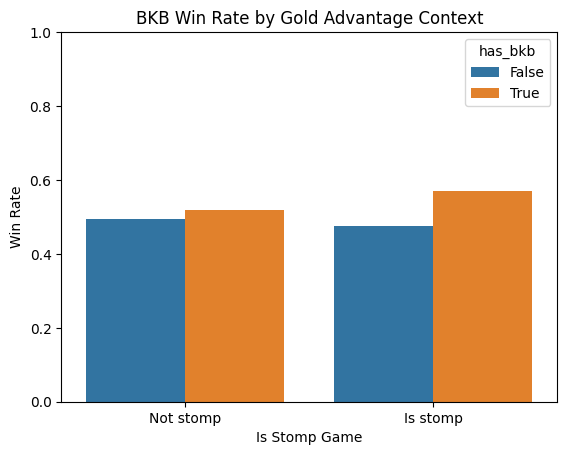

In [25]:
sns.barplot(
    data=bkb_gold_result_03,
    x='is_stomp',
    y='win',
    hue='has_bkb'
)

plt.title("BKB Win Rate by Gold Advantage Context")
plt.xlabel("Is Stomp Game")

plt.xticks([0,1], ["Not stomp", "Is stomp"])
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.show()

Unexpectedly, the result shows that BKB appears to have a stronger impact in one-sided ("stomp") games than in more balanced matches. 

However, this result should be interpreted with caution. There are several possible explanations:

- In stomp games, the winning team tends to dominate overall, and players on the winning side are more likely to both purchase BKB and win the game. Moreover, purchasing bkb also might cause their domination. This creates a correlation between BKB purchase and victory that may not be causal.
- In non-stomp (more balanced) games, both teams may purchase BKB more frequently, reducing the observable difference in win rates between players with and without BKB.

Therefore, the current result likely reflects both strategic item usage and underlying game dynamics, rather than a direct causal effect of BKB alone.

To further improve this analysis, we could consider additional dimensions:

- The timing of BKB purchase (early vs late)
- Changes in gold accumulation after purchasing BKB
- Team-level item advantage (e.g., number of BKBs purchased per team)
- Hero-specific contexts (some heroes benefit more from BKB than others)

These extensions would help us better isolate the true impact of itemization decisions.

We now move on to a more context-aware analysis of itemization strategies.

# Part 4:  itemization strategies are under hero contexts

### 4.1 Does a carry hero benefit more from BKB?

To classify hero roles, we utilize the official OpenDota API, which provides role labels for each hero (e.g., Carry, Support, Nuker).

We define a hero as a "carry" if the role list includes the "Carry" tag. This allows us to avoid manual classification and ensures consistency with established game knowledge.

We then compare the win rate of players who purchase BKB versus those who do not, separately for carry and non-carry heroes.

This analysis helps us understand whether BKB provides greater benefits to heroes that rely more heavily on sustained damage and item scaling.

In [26]:
# We already have this during data preparation stage.

heroes[:5]

[{'id': 1,
  'name': 'npc_dota_hero_antimage',
  'localized_name': 'Anti-Mage',
  'primary_attr': 'agi',
  'attack_type': 'Melee',
  'roles': ['Carry', 'Escape', 'Nuker'],
  'legs': 2},
 {'id': 2,
  'name': 'npc_dota_hero_axe',
  'localized_name': 'Axe',
  'primary_attr': 'str',
  'attack_type': 'Melee',
  'roles': ['Initiator', 'Durable', 'Disabler', 'Carry'],
  'legs': 2},
 {'id': 3,
  'name': 'npc_dota_hero_bane',
  'localized_name': 'Bane',
  'primary_attr': 'all',
  'attack_type': 'Ranged',
  'roles': ['Support', 'Disabler', 'Nuker', 'Durable'],
  'legs': 4},
 {'id': 4,
  'name': 'npc_dota_hero_bloodseeker',
  'localized_name': 'Bloodseeker',
  'primary_attr': 'agi',
  'attack_type': 'Melee',
  'roles': ['Carry', 'Disabler', 'Nuker', 'Initiator'],
  'legs': 2},
 {'id': 5,
  'name': 'npc_dota_hero_crystal_maiden',
  'localized_name': 'Crystal Maiden',
  'primary_attr': 'int',
  'attack_type': 'Ranged',
  'roles': ['Support', 'Disabler', 'Nuker'],
  'legs': 2}]

In [27]:
hero_df.head()

,id,name,localized_name,primary_attr,attack_type,roles,legs
0,1,npc_dota_hero_antimage,Anti-Mage,agi,Melee,"[Carry, Escape, Nuker]",2
1,2,npc_dota_hero_axe,Axe,str,Melee,"[Initiator, Durable, Disabler, Carry]",2
2,3,npc_dota_hero_bane,Bane,all,Ranged,"[Support, Disabler, Nuker, Durable]",4
3,4,npc_dota_hero_bloodseeker,Bloodseeker,agi,Melee,"[Carry, Disabler, Nuker, Initiator]",2
4,5,npc_dota_hero_crystal_maiden,Crystal Maiden,int,Ranged,"[Support, Disabler, Nuker]",2


In [28]:
# Define a carry hero if it has a "Carry" label

hero_df['is_carry'] = hero_df['roles'].apply(lambda x: 'Carry' in x)

In [29]:
hero_roles = hero_df[['id', 'localized_name', 'is_carry']]
hero_roles = hero_roles.rename(columns={'id': 'hero_id'})

In [30]:
players_03 = players_03.merge(
    hero_roles,
    on='hero_id',
    how='left'
)

In [31]:
carry_result = (
    players_03
    .groupby(['is_carry', 'has_bkb'])['win']
    .mean()
    .reset_index()
)

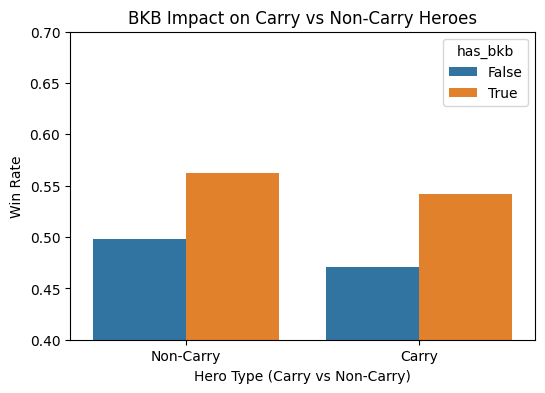

In [32]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=carry_result,
    x='is_carry',
    y='win',
    hue='has_bkb'
)

plt.title("BKB Impact on Carry vs Non-Carry Heroes")
plt.xlabel("Hero Type (Carry vs Non-Carry)")
plt.ylabel("Win Rate")
plt.ylim(0.4, 0.7)

plt.xticks([0,1], ["Non-Carry", "Carry"])

plt.show()

### Result interpretation

From the comparison between carry and non-carry heroes, we can derive several additional observations:

1. **Baseline difference without BKB**
   Non-carry heroes without BKB tend to have a higher win rate than carry heroes without BKB.
   A possible explanation is that carry heroes are more dependent on key items like BKB to function effectively. 
   If a carry hero does not purchase BKB, it may indicate that the player is underfarmed or the team is in a disadvantageous position.

2. **Interpretation of BKB purchase on non-carry heroes**
   When non-carry heroes purchase BKB, their win rate becomes even higher than carry heroes with BKB.
   This is likely because non-carry heroes typically do not prioritize BKB. Therefore, when they are able to afford it, it often indicates that the team is already in a strong economic position.

3. **Consistent marginal effect of BKB**
   Despite differences in absolute win rates, the increase in win rate associated with purchasing BKB is relatively consistent across both groups (approximately 7%).
   This suggests that BKB provides a stable performance benefit regardless of hero type.

Overall, BKB appears to be an important item for improving win probability, but its observed impact is influenced by player role and underlying economic conditions.

In addition, OpenDota role labels are hero-based rather than match-specific. A hero without the "Carry" tag may still be played as an important core in a professional match.

Therefore, this result should be interpreted as correlation rather than causation. BKB purchase is associated with higher win rate, but the effect is mixed with hero role, economy, and overall team advantage.

In [33]:
carry_summary = (
    players_03
    .groupby(['is_carry', 'has_bkb'])
    .agg(
        win_rate=('win', 'mean'),
        count=('win', 'count')
    )
    .reset_index()
)

carry_summary

,is_carry,has_bkb,win_rate,count
0,False,False,0.497949,10240
1,False,True,0.562500,1392
2,True,False,0.470836,8315
3,True,True,0.542195,4183


In [34]:
bkb_purchase_rate = (
    players_03
    .groupby('is_carry')['has_bkb']
    .mean()
    .reset_index()
    .rename(columns={'has_bkb': 'bkb_purchase_rate'})
)

bkb_purchase_rate

,is_carry,bkb_purchase_rate
0,False,0.119670
1,True,0.334694


This result shows that carry heroes have significanly higher bkb purchase rate.

# 4.2 What heroes are best with bkbs?

To extend our analysis to a scalable framework, we implement hero-level aggregation using PySpark. We first construct player-level features such as win and BKB purchase indicators, then join hero metadata from OpenDota to obtain hero names.

We then compute win rates for each hero when purchasing BKB, filtering out heroes with insufficient samples.

In [35]:
from pyspark.sql import SparkSession

spark_03 = SparkSession.builder.appName("DotaAnalysis").getOrCreate()

spark_df_03 = spark_03.read.csv("202603/players.csv", header=True, inferSchema=True)
spark_df_03.printSchema()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/05 10:39:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

root
 |-- player_slot: integer (nullable = true)
 |-- obs_placed: double (nullable = true)
 |-- sen_placed: double (nullable = true)
 |-- creeps_stacked: double (nullable = true)
 |-- camps_stacked: double (nullable = true)
 |-- rune_pickups: double (nullable = true)
 |-- firstblood_claimed: double (nullable = true)
 |-- teamfight_participation: double (nullable = true)
 |-- towers_killed: double (nullable = true)
 |-- roshans_killed: double (nullable = true)
 |-- observers_placed: double (nullable = true)
 |-- stuns: double (nullable = true)
 |-- max_hero_hit: string (nullable = true)
 |-- times: string (nullable = true)
 |-- gold_t: string (nullable = true)
 |-- lh_t: string (nullable = true)
 |-- dn_t: string (nullable = true)
 |-- xp_t: string (nullable = true)
 |-- obs_log: string (nullable = true)
 |-- sen_log: string (nullable = true)
 |-- obs_left_log: string (nullable = true)
 |-- sen_left_log: string (nullable = true)
 |-- purchase_log: string (nullable = true)
 |-- kills_log

Firstly, simply sort heroes by their win rate when they had purchased bkb

In [36]:
from pyspark.sql import functions as F

# Reduce to needed columns
spark_players_03 = spark_df_03.select(
    "match_id",
    "player_slot",
    "hero_id",
    "purchase",
    "radiant_win"
)

# Create win column
spark_players_03 = spark_players_03.withColumn(
    "win",
    F.when(F.col("player_slot") < 128, F.col("radiant_win"))
     .otherwise(~F.col("radiant_win"))
)

# Create has_bkb column
spark_players_03 = spark_players_03.withColumn(
    "has_bkb",
    F.col("purchase").contains("black_king_bar")
)

In [37]:
hero_roles_spark_03 = spark_03.createDataFrame(
    hero_roles[["hero_id", "localized_name"]]
)

spark_players_03 = spark_players_03.join(
    hero_roles_spark_03,
    on="hero_id",
    how="left"
)

In [38]:
# Filter out heroes who have less than 10 games with bkb
hero_bkb_result_spark_03 = (
    spark_players_03
    .filter(F.col("has_bkb") == True)
    .groupBy("localized_name")
    .agg(
        F.avg(F.col("win").cast("int")).alias("bkb_win_rate"),
        F.count("*").alias("bkb_games")
    )
    .filter(F.col("bkb_games") >= 10)
    .orderBy(F.col("bkb_win_rate").desc())
)


hero_bkb_result_spark_03.show(10, truncate=False)

+----------------+------------------+---------+
|localized_name  |bkb_win_rate      |bkb_games|
+----------------+------------------+---------+
|Wraith King     |0.8               |10       |
|Phoenix         |0.7058823529411765|17       |
|Alchemist       |0.6976744186046512|43       |
|Brewmaster      |0.6923076923076923|13       |
|Tidehunter      |0.6818181818181818|22       |
|Largo           |0.6782608695652174|115      |
|Spirit Breaker  |0.6666666666666666|21       |
|Sand King       |0.6567164179104478|67       |
|Legion Commander|0.6551724137931034|29       |
|Huskar          |0.6538461538461539|52       |
+----------------+------------------+---------+
only showing top 10 rows



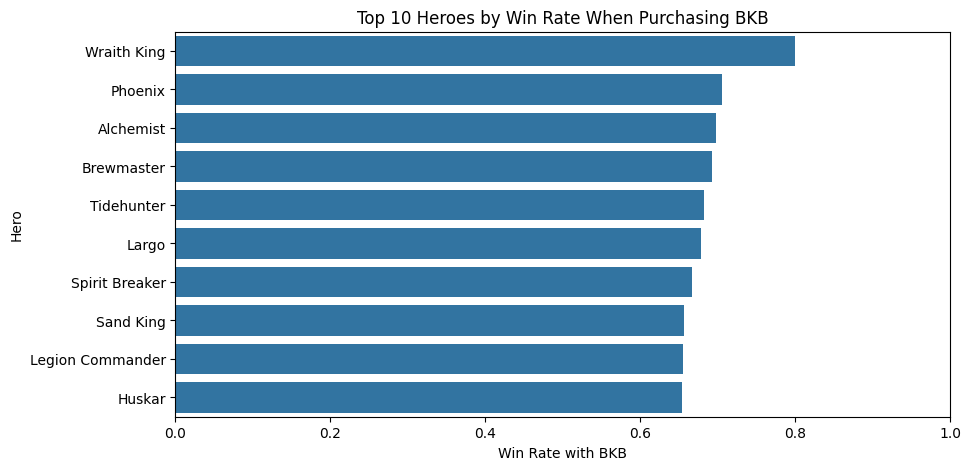

In [39]:
top_bkb_heroes_pd_03 = hero_bkb_result_spark_03.limit(10).toPandas()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_bkb_heroes_pd_03,
    x="bkb_win_rate",
    y="localized_name"
)

plt.title("Top 10 Heroes by Win Rate When Purchasing BKB")
plt.xlabel("Win Rate with BKB")
plt.ylabel("Hero")
plt.xlim(0, 1)
plt.show()

While some heroes show high win rates when purchasing BKB, this does not necessarily indicate that BKB is the cause of their success.

For example:
- Some heroes naturally have high win rates regardless of itemization.
- Support heroes rarely purchase BKB, but when they do, it often indicates a highly favorable game state.

To address this, we measure the *impact* of BKB by comparing win rates with and without BKB for each hero.

This allows us to isolate the relative benefit of purchasing BKB rather than relying on absolute win rates.

We define:

### BKB Impact = win_rate_with_bkb - win_rate_without_bkb

In [40]:
hero_bkb_compare_03 = (
    spark_players_03
    .groupBy("localized_name", "has_bkb")
    .agg(
        F.avg(F.col("win").cast("int")).alias("win_rate"),
        F.count("*").alias("games")
    )
)

In [41]:
# Convert long format into wide format using pivot

hero_bkb_pivot_03 = (
    hero_bkb_compare_03
    .groupBy("localized_name")
    .pivot("has_bkb", [False, True])
    .agg(F.first("win_rate"))
    .withColumnRenamed("false", "win_no_bkb")
    .withColumnRenamed("true", "win_with_bkb")
)

In [42]:
hero_bkb_impact_03 = (
    hero_bkb_pivot_03
    .withColumn(
        "bkb_impact",
        F.col("win_with_bkb") - F.col("win_no_bkb")
    )
    .orderBy(F.col("bkb_impact").desc())
)

In [43]:
# Filter out null data
hero_bkb_impact_03 = hero_bkb_impact_03.filter(
    (F.col("win_with_bkb").isNotNull()) &
    (F.col("win_no_bkb").isNotNull())
)

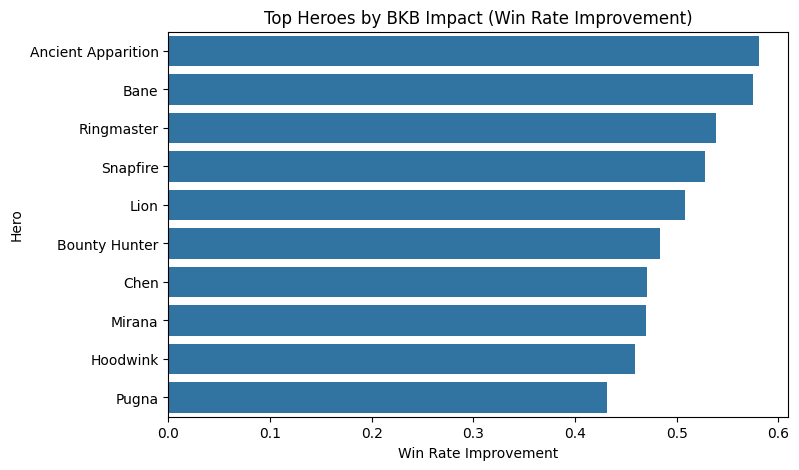

In [44]:
hero_pd_03 = hero_bkb_impact_03.limit(10).toPandas()

plt.figure(figsize=(8,5))
sns.barplot(
    data=hero_pd_03,
    y="localized_name",
    x="bkb_impact"
)

plt.title("Top Heroes by BKB Impact (Win Rate Improvement)")
plt.xlabel("Win Rate Improvement")
plt.ylabel("Hero")
plt.show()

### Interpretation of BKB Impact Results

From the results above, we observe that heroes with the highest apparent "BKB impact" are predominantly support heroes.

However, this does not necessarily imply that BKB itself is the primary cause of the increased win rate. Instead, this pattern is likely influenced by underlying game context:

- Support heroes typically have lower farm priority and limited gold income.
- If a support hero is able to afford a BKB, it often indicates that their team already has a significant economic advantage.

Therefore, the observed improvement in win rate is likely correlated with overall game advantage rather than being directly caused by the item purchase itself.

This highlights an important limitation of our current analysis:  
we are not controlling for confounding variables such as total team gold or game state.

#### This suggests that raw win rate comparisons can be misleading without proper contextual controls.

In future work, this can be addressed by introducing a controlled comparison:
- Evaluate BKB impact under similar economic conditions
- Measure win rate differences while holding gold advantage constant

Moreover, future work could control for confounding variables such as gold advantage or game duration to further isolate causal effects.

For now, we leave this extension for future exploration and proceed to the next analysis section.

# 4.3 hero vs hero matchup （Hero's win rate with bkb when matchup with different enemy heroes）

To further refine our analysis, we introduce hero-to-hero matchups. Instead of analyzing BKB usage in isolation, we examine how its effectiveness varies depending on the opponent lineup.

Each player is paired with all 5 enemy heroes, resulting in duplicated observations per match. However, this does not affect relative win rate calculations.

In [45]:
# Add team column
spark_players_03 = spark_players_03.withColumn(
    "team",
    F.when(F.col("player_slot") < 128, F.lit("radiant"))
     .otherwise(F.lit("dire"))
)

# Self join: each player is paired with all enemy players in the same match
matchups_03 = (
    spark_players_03.alias("self")
    .join(
        spark_players_03.alias("enemy"),
        on="match_id",
        how="inner"
    )
    .filter(F.col("self.team") != F.col("enemy.team"))
)

In [46]:
# Extract useful features

matchups_clean_03 = matchups_03.select(
    F.col("match_id"),
    F.col("self.hero_id").alias("hero_id"),
    F.col("self.localized_name").alias("hero_name"),
    F.col("self.has_bkb").alias("has_bkb"),
    F.col("self.win").alias("win"),
    F.col("enemy.hero_id").alias("enemy_hero_id"),
    F.col("enemy.localized_name").alias("enemy_hero_name")
)

matchups_clean_03.show(10, truncate=False)

+----------+-------+-----------------+-------+-----+-------------+---------------+
|match_id  |hero_id|hero_name        |has_bkb|win  |enemy_hero_id|enemy_hero_name|
+----------+-------+-----------------+-------+-----+-------------+---------------+
|8721178344|93     |Slark            |true   |false|29           |Tidehunter     |
|8721178344|13     |Puck             |false  |false|29           |Tidehunter     |
|8721178344|37     |Warlock          |false  |false|29           |Tidehunter     |
|8721178344|96     |Centaur Warrunner|true   |false|29           |Tidehunter     |
|8721178344|107    |Earth Spirit     |false  |false|29           |Tidehunter     |
|8714180064|64     |Jakiro           |false  |false|19           |Tiny           |
|8714180064|100    |Tusk             |false  |false|19           |Tiny           |
|8714180064|138    |Muerta           |false  |false|19           |Tiny           |
|8714180064|28     |Slardar          |true   |false|19           |Tiny           |
|871

In [47]:
hero_enemy_bkb_result_03 = (
    matchups_clean_03
    .filter(F.col("has_bkb") == True)
    .groupBy("hero_name", "enemy_hero_name")
    .agg(
        F.avg(F.col("win").cast("int")).alias("bkb_win_rate"),
        F.count("*").alias("bkb_matchup_records")
    )
    .filter(F.col("bkb_matchup_records") >= 10)
    .orderBy(F.col("bkb_win_rate").desc())
)

hero_enemy_bkb_result_03.show(20, truncate=False)

[Stage 62:>                                                         (0 + 1) / 1]

+-------------+---------------+------------------+-------------------+
|hero_name    |enemy_hero_name|bkb_win_rate      |bkb_matchup_records|
+-------------+---------------+------------------+-------------------+
|Shadow Shaman|Windranger     |0.9090909090909091|11                 |
|Dragon Knight|Ursa           |0.9090909090909091|11                 |
|Sand King    |Jakiro         |0.8571428571428571|14                 |
|Invoker      |Tiny           |0.8461538461538461|13                 |
|Luna         |Warlock        |0.8421052631578947|19                 |
|Largo        |Shadow Fiend   |0.8421052631578947|19                 |
|Windranger   |Bristleback    |0.8333333333333334|12                 |
|Ember Spirit |Razor          |0.8333333333333334|12                 |
|Windranger   |Kez            |0.8235294117647058|17                 |
|Muerta       |Bristleback    |0.8181818181818182|11                 |
|Storm Spirit |Razor          |0.8181818181818182|11                 |
|Windr

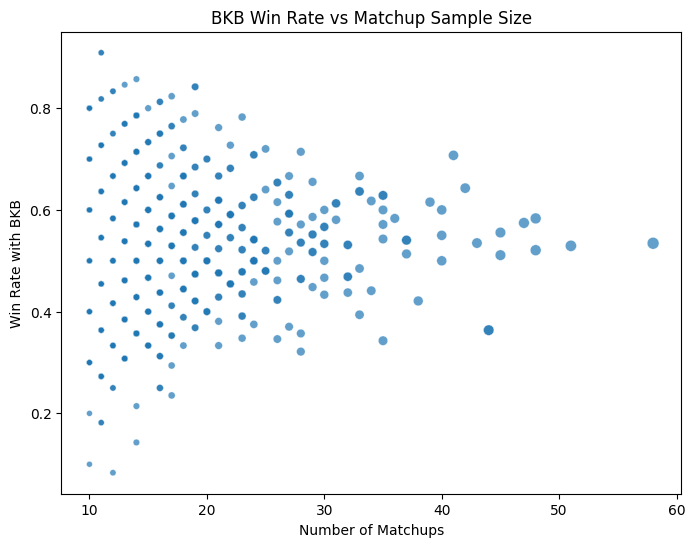

In [50]:
plt.figure(figsize=(8,6))
df = hero_enemy_bkb_result_03.toPandas()
sns.scatterplot(
    data=df,
    x="bkb_matchup_records",
    y="bkb_win_rate",
    size="bkb_matchup_records",
    alpha=0.7,
    legend=False # remove legend here because there are too many hero categories.
)

plt.title("BKB Win Rate vs Matchup Sample Size")
plt.xlabel("Number of Matchups")
plt.ylabel("Win Rate with BKB")

plt.show()

#### Interpretation:

We can see that win rates become more stable as the sample size increases, which suggests that extreme values on the left may not be reliable.

These can be seen more clearly with a box plot:

In [51]:
bins = [0, 15, 25, 35, 50, 100]
labels = ["0-15", "15-25", "25-35", "35-50", "50+"]

df["match_bin"] = pd.cut(df["bkb_matchup_records"], bins=bins, labels=labels)

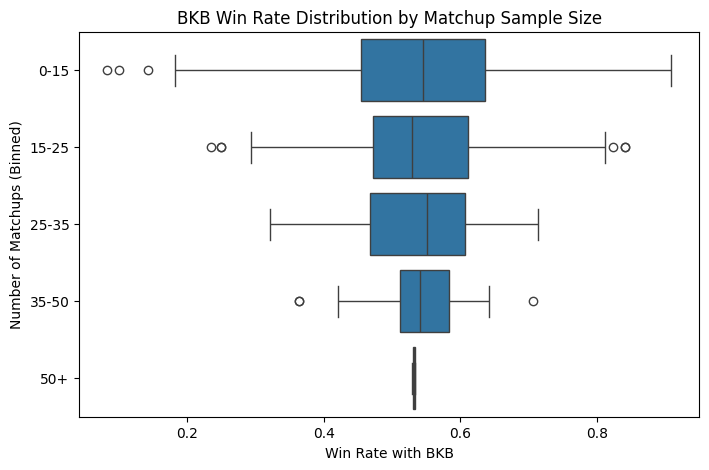

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="bkb_win_rate",
    y="match_bin"
)

plt.title("BKB Win Rate Distribution by Matchup Sample Size")
plt.xlabel("Win Rate with BKB")
plt.ylabel("Number of Matchups (Binned)")

plt.show()

We group matchups by sample size and examine the distribution of win rates within each group.

We observe that smaller sample sizes produce a much wider distribution,
while larger samples lead to more stable and concentrated win rates.

This reinforces that extreme values are often due to limited data.

We still have a similar problem that a hero might be already good against some hero either with or without bkb, so let's add

#### BKB Impact=WinRate(With BKB)−WinRate(Without BKB)

In [53]:
hero_enemy_compare_03 = (
    matchups_clean_03
    .groupBy("hero_name", "enemy_hero_name", "has_bkb")
    .agg(
        F.avg(F.col("win").cast("int")).alias("win_rate"),
        F.count("*").alias("games")
    )
)

In [54]:
hero_enemy_pivot_03 = (
    hero_enemy_compare_03
    .groupBy("hero_name", "enemy_hero_name")
    .pivot("has_bkb", [False, True])
    .agg(F.first("win_rate"))
    .withColumnRenamed("false", "win_no_bkb")
    .withColumnRenamed("true", "win_with_bkb")
)


hero_enemy_pivot_03.show(20, truncate=False)

[Stage 113:>                                                        (0 + 1) / 1]

+-------------------+----------------+-------------------+------------+
|hero_name          |enemy_hero_name |win_no_bkb         |win_with_bkb|
+-------------------+----------------+-------------------+------------+
|Centaur Warrunner  |Earthshaker     |0.3333333333333333 |NULL        |
|Shadow Demon       |Templar Assassin|0.54               |1.0         |
|Marci              |Silencer        |0.4                |1.0         |
|Nature's Prophet   |Phantom Assassin|1.0                |1.0         |
|Keeper of the Light|Underlord       |0.6666666666666666 |NULL        |
|Treant Protector   |Sven            |1.0                |NULL        |
|Wraith King        |Muerta          |0.0                |1.0         |
|Dawnbreaker        |Nature's Prophet|1.0                |NULL        |
|Shadow Fiend       |Huskar          |0.45454545454545453|0.5         |
|Phantom Assassin   |Grimstroke      |NULL               |0.5         |
|Slark              |Hoodwink        |1.0                |0.4   

In [55]:
# Also pivot our game counts

hero_enemy_count_pivot_03 = (
    hero_enemy_compare_03
    .groupBy("hero_name", "enemy_hero_name")
    .pivot("has_bkb", [False, True])
    .agg(F.first("games"))
    .withColumnRenamed("false", "games_no_bkb")
    .withColumnRenamed("true", "games_with_bkb")
)

hero_enemy_count_pivot_03.show(20, truncate=False)

+-------------------+----------------+------------+--------------+
|hero_name          |enemy_hero_name |games_no_bkb|games_with_bkb|
+-------------------+----------------+------------+--------------+
|Centaur Warrunner  |Earthshaker     |3           |NULL          |
|Shadow Demon       |Templar Assassin|50          |1             |
|Marci              |Silencer        |5           |1             |
|Nature's Prophet   |Phantom Assassin|1           |1             |
|Keeper of the Light|Underlord       |9           |NULL          |
|Treant Protector   |Sven            |4           |NULL          |
|Wraith King        |Muerta          |1           |1             |
|Dawnbreaker        |Nature's Prophet|2           |NULL          |
|Shadow Fiend       |Huskar          |11          |2             |
|Phantom Assassin   |Grimstroke      |NULL        |4             |
|Slark              |Hoodwink        |6           |5             |
|Crystal Maiden     |Mars            |14          |2          

In [56]:
hero_enemy_bkb_impact_03 = (
    hero_enemy_pivot_03
    .join(
        hero_enemy_count_pivot_03,
        on=["hero_name", "enemy_hero_name"],
        how="inner"
    )
    .filter(
        (F.col("win_no_bkb").isNotNull()) &
        (F.col("win_with_bkb").isNotNull()) &
        (F.col("games_no_bkb") >= 10) &
        (F.col("games_with_bkb") >= 10)
    )
    .withColumn(
        "bkb_impact",
        F.col("win_with_bkb") - F.col("win_no_bkb")
    )
    .orderBy(F.col("bkb_impact").desc())
)

hero_enemy_bkb_impact_03.show(20, truncate=False)

+-------------+---------------+-------------------+------------------+------------+--------------+-------------------+
|hero_name    |enemy_hero_name|win_no_bkb         |win_with_bkb      |games_no_bkb|games_with_bkb|bkb_impact         |
+-------------+---------------+-------------------+------------------+------------+--------------+-------------------+
|Luna         |Warlock        |0.2                |0.8421052631578947|25          |19            |0.6421052631578947 |
|Mars         |Ursa           |0.0                |0.6086956521739131|11          |23            |0.6086956521739131 |
|Luna         |Tusk           |0.125              |0.6923076923076923|16          |13            |0.5673076923076923 |
|Dragon Knight|Beastmaster    |0.16666666666666666|0.7142857142857143|12          |14            |0.5476190476190477 |
|Windranger   |Beastmaster    |0.2857142857142857 |0.8125            |14          |16            |0.5267857142857143 |
|Tiny         |Tidehunter     |0.125            

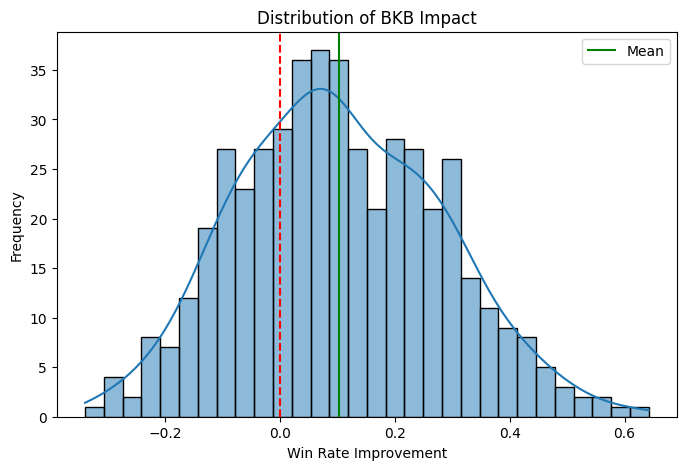

In [57]:
df = hero_enemy_bkb_impact_03.toPandas()
plt.figure(figsize=(8,5))

sns.histplot(df["bkb_impact"], bins=30, kde=True)

plt.axvline(0, color='red', linestyle='--')

plt.axvline(df["bkb_impact"].mean(), color='green', label='Mean')

plt.legend()

plt.title("Distribution of BKB Impact")
plt.xlabel("Win Rate Improvement")
plt.ylabel("Frequency")

plt.show()

We observe that most BKB impacts are positive, as shown by the distribution being concentrated on the right side of zero.
The mean improvement is around 0.1, indicating that BKB generally provides a moderate win rate boost.

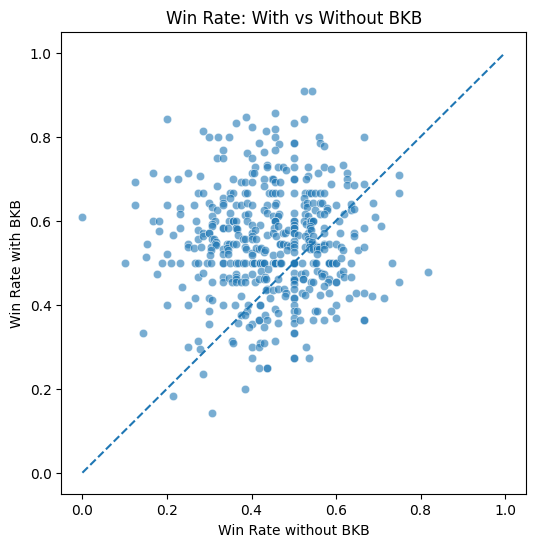

In [58]:
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=df,
    x="win_no_bkb",
    y="win_with_bkb",
    alpha=0.6
)

plt.plot([0,1],[0,1], linestyle="--")  # diagonal

plt.title("Win Rate: With vs Without BKB")
plt.xlabel("Win Rate without BKB")
plt.ylabel("Win Rate with BKB")
plt.show()

The scatter plot shows that most points lie above the diagonal, indicating that BKB generally improves win rate. However, the effect is modest and concentrated around the center, suggesting that BKB acts as a marginal advantage rather than a decisive factor. Additionally, the distribution implies a potential selection bias, where players are more likely to purchase BKB in already favorable game states.

# 4.4 Beyond bkb

Having studied bkb for so long, we can extend our method to analyze how other itemization strategies varies depending on the opponent lineup.

### Given (hero, enemy hero), which item leads to the highest win rate?

This analysis extends beyond BKB by identifying the optimal item choices under specific hero matchups. Instead of focusing on a single item, we evaluate which item yields the highest win rate given both the player’s hero and the opponent’s hero.

In [59]:
# Extract useful features

matchups_clean_03 = matchups_03.select(
    F.col("match_id"),
    F.col("self.hero_id").alias("hero_id"),
    F.col("self.localized_name").alias("hero_name"),
    F.col("self.has_bkb").alias("has_bkb"),
    F.col("self.purchase").alias("purchase"),
    F.col("self.win").alias("win"),
    F.col("enemy.hero_id").alias("enemy_hero_id"),
    F.col("enemy.localized_name").alias("enemy_hero_name")
)

matchups_clean_03.show(10, truncate=False)

+----------+-------+----------+-------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+-------------+-----------------+
|match_id  |hero_id|hero_name |has_bkb|purchase                                           

In [60]:
from pyspark.sql.types import MapType, StringType, IntegerType

# Convert purchase string into a Spark map
matchups_clean_03 = matchups_clean_03.withColumn(
    "purchase_json",
    F.regexp_replace(F.col("purchase"), "'", '"')
).withColumn(
    "purchase_map",
    F.from_json(
        F.col("purchase_json"),
        MapType(StringType(), IntegerType())
    )
)

In [61]:
items_df_03 = (
    matchups_clean_03
    .select(
        "match_id",
        "hero_id",
        "hero_name",
        "enemy_hero_id",
        "enemy_hero_name",
        "win",
        F.explode(F.map_entries("purchase_map")).alias("item_entry")
    )
    .select(
        "match_id",
        "hero_id",
        "hero_name",
        "enemy_hero_id",
        "enemy_hero_name",
        "win",
        F.col("item_entry.key").alias("item"),
        F.col("item_entry.value").alias("item_count")
    )
)

items_df_03.show(10, truncate=False)

+----------+-------+----------+-------------+---------------+----+---------------------+----------+
|match_id  |hero_id|hero_name |enemy_hero_id|enemy_hero_name|win |item                 |item_count|
+----------+-------+----------+-------------+---------------+----+---------------------+----------+
|8721178344|29     |Tidehunter|93           |Slark          |true|wind_lace            |3         |
|8721178344|29     |Tidehunter|93           |Slark          |true|recipe_magic_wand    |1         |
|8721178344|29     |Tidehunter|93           |Slark          |true|recipe_ancient_janggo|1         |
|8721178344|29     |Tidehunter|93           |Slark          |true|gauntlets            |3         |
|8721178344|29     |Tidehunter|93           |Slark          |true|point_booster        |2         |
|8721178344|29     |Tidehunter|93           |Slark          |true|staff_of_wizardry    |1         |
|8721178344|29     |Tidehunter|93           |Slark          |true|blink                |1         |


In [62]:
hero_enemy_item_result_03 = (
    items_df_03
    .groupBy("hero_name", "enemy_hero_name", "item")
    .agg(
        F.avg(F.col("win").cast("int")).alias("item_win_rate"),
        F.count("*").alias("item_matchup_records")
    )
    .filter(F.col("item_matchup_records") >= 10) # filter out items that's bought less than 10 times
    .filter(~F.col("item").startswith("recipe_")) # filter out recipe items
    .orderBy(F.col("item_win_rate").desc())
)

hero_enemy_item_result_03.show(20, truncate=False)

[Stage 251:>                                                        (0 + 2) / 2]

+----------------+----------------+-----------------+-------------+--------------------+
|hero_name       |enemy_hero_name |item             |item_win_rate|item_matchup_records|
+----------------+----------------+-----------------+-------------+--------------------+
|Largo           |Tinker          |magic_wand       |1.0          |10                  |
|Weaver          |Razor           |greater_crit     |1.0          |10                  |
|Hoodwink        |Kez             |dust             |1.0          |11                  |
|Luna            |Warlock         |satanic          |1.0          |10                  |
|Treant Protector|Spirit Breaker  |smoke_of_deceit  |1.0          |11                  |
|Warlock         |Shadow Shaman   |blade_of_alacrity|1.0          |13                  |
|Treant Protector|Spirit Breaker  |tango            |1.0          |10                  |
|Warlock         |Ringmaster      |gem              |1.0          |10                  |
|Windranger      |Kez

**But still, raw item win rate can be misleading because a hero may already counter the enemy hero regardless of item choice. Therefore, we calculate item impact instead of only using absolute win rate.**

### Item Impact = WinRate(with item) - WinRate(without item)

This allows us to better estimate how much an item is associated with improved performance under a specific hero matchup.

In [63]:
# All hero-enemy-item combinations with / without each item
# First get all unique hero-enemy-item combinations
all_items_03 = items_df_03.select(
    "hero_name", "enemy_hero_name", "item"
).distinct()

# Create base matchup-player records
base_matchups_03 = matchups_clean_03.select(
    "match_id",
    "hero_name",
    "enemy_hero_name",
    "purchase",
    "win"
)

# Join each hero-enemy pair with candidate items
item_presence_03 = (
    base_matchups_03
    .join(
        all_items_03,
        on=["hero_name", "enemy_hero_name"],
        how="inner"
    )
    .withColumn(
        "has_item",
        F.col("purchase").contains(F.col("item"))
    )
)

item_impact_compare_03 = (
    item_presence_03
    .groupBy("hero_name", "enemy_hero_name", "item", "has_item")
    .agg(
        F.avg(F.col("win").cast("int")).alias("win_rate"),
        F.count("*").alias("games")
    )
)

In [64]:
item_impact_pivot_03 = (
    item_impact_compare_03
    .groupBy("hero_name", "enemy_hero_name", "item")
    .pivot("has_item", [False, True])
    .agg(F.first("win_rate"))
    .withColumnRenamed("false", "win_without_item")
    .withColumnRenamed("true", "win_with_item")
)

item_count_pivot_03 = (
    item_impact_compare_03
    .groupBy("hero_name", "enemy_hero_name", "item")
    .pivot("has_item", [False, True])
    .agg(F.first("games"))
    .withColumnRenamed("false", "games_without_item")
    .withColumnRenamed("true", "games_with_item")
)

item_impact_03 = (
    item_impact_pivot_03
    .join(
        item_count_pivot_03,
        on=["hero_name", "enemy_hero_name", "item"],
        how="inner"
    )
    .filter(
        (F.col("win_without_item").isNotNull()) &
        (F.col("win_with_item").isNotNull()) &
        (F.col("games_without_item") >= 10) &
        (F.col("games_with_item") >= 10) &
        (~F.col("item").startswith("recipe_"))
    )
    .withColumn(
        "item_impact",
        F.col("win_with_item") - F.col("win_without_item")
    )
    .orderBy(F.col("item_impact").desc())
)

item_impact_03.show(20, truncate=False)

26/05/05 10:48:23 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/05 10:48:23 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/05 10:48:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/05 10:48:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
[Stage 302:============================>                            (1 + 1) / 2]

+---------+----------------+-------------------+--------------------+------------------+------------------+---------------+------------------+
|hero_name|enemy_hero_name |item               |win_without_item    |win_with_item     |games_without_item|games_with_item|item_impact       |
+---------+----------------+-------------------+--------------------+------------------+------------------+---------------+------------------+
|Puck     |Templar Assassin|soul_booster       |0.17647058823529413 |1.0               |17                |11             |0.8235294117647058|
|Puck     |Templar Assassin|energy_booster     |0.17647058823529413 |1.0               |17                |11             |0.8235294117647058|
|Puck     |Templar Assassin|vitality_booster   |0.17647058823529413 |1.0               |17                |11             |0.8235294117647058|
|Slark    |Treant Protector|eagle              |0.09090909090909091 |0.9               |11                |10             |0.8090909090909091|

26/05/05 10:50:08 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/05 10:50:08 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/05 10:50:36 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/05 10:50:36 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
                                                                                

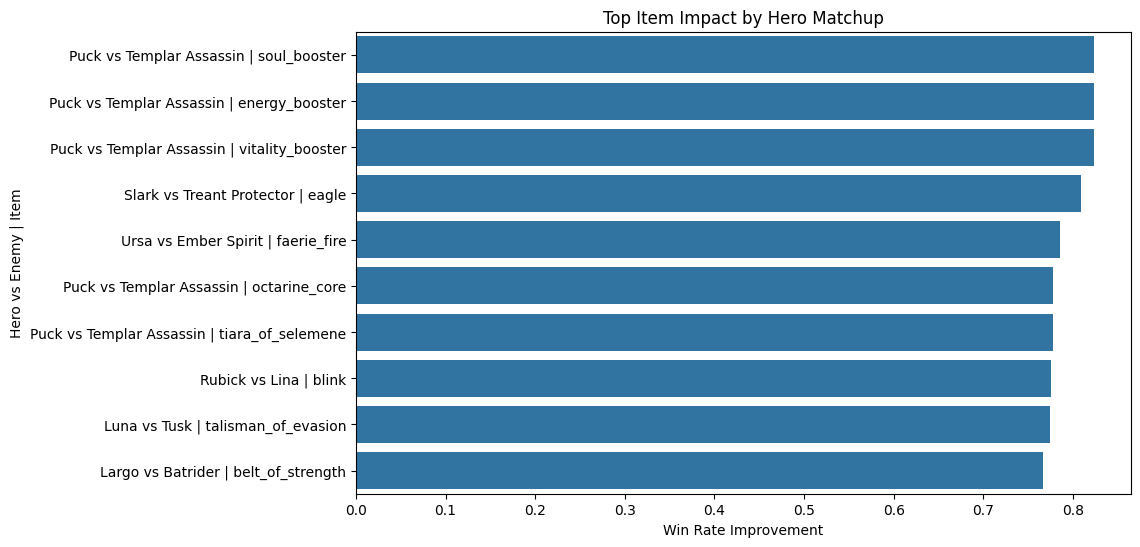

In [65]:
top_item_impact_pd_03 = item_impact_03.limit(10).toPandas()

top_item_impact_pd_03["label"] = (
    top_item_impact_pd_03["hero_name"]
    + " vs "
    + top_item_impact_pd_03["enemy_hero_name"]
    + " | "
    + top_item_impact_pd_03["item"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_item_impact_pd_03,
    x="item_impact",
    y="label"
)

plt.title("Top Item Impact by Hero Matchup")
plt.xlabel("Win Rate Improvement")
plt.ylabel("Hero vs Enemy | Item")
plt.show()

The results show that item effectiveness is highly context-dependent, and no single item dominates across all matchups.

This suggests that itemization in Dota 2 is not only hero-dependent but also strongly influenced by the enemy composition, which reinforces the idea that optimal itemization is conditional and adaptive rather than static.

# Part 5: Possible future work

- Compare itemization strategy trends across different months and game patches.

- Given a specific hero and enemy hero composition, which item leads to the highest win rate?

- Given a specific hero and enemy hero composition, which item combinations lead to the highest win rate?

- Given a specific hero and enemy hero composition, what is the optimal timing to purchase a specific item?

Future Extension with Machine Learning:

This analysis can be extended into a supervised learning framework.
We can train a model to predict win probability based on:

- hero
- enemy hero composition
- item choices

Such a model can help isolate the marginal effect of each item,
while controlling for confounding factors like hero strength and matchups.

This would provide a more causal interpretation compared to simple win rate comparisons.